In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [234]:
pd.set_option('display.max_columns', None)

In [235]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [236]:
df.head()

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.0,0,1,0,0,0,1,43.0
2,flat,tulip monsella,7.40,sector 53,33198.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.0,0,0,0,0,0,1,35.0
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.0,0,0,0,1,0,1,59.0


In [237]:
df.columns

Index(['property_type', 'society', 'price', 'sector', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

/tmp/ipykernel_5910/3000028571.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

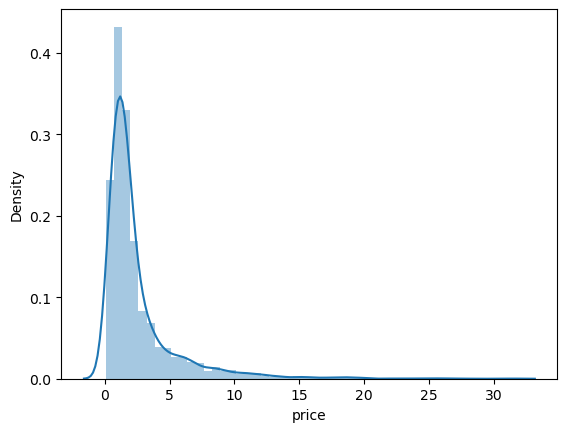

In [238]:
# price

sns.distplot(df['price'])

In [239]:
df['price'].describe()

count    3862.000000
mean        2.490067
std         2.930200
min         0.070000
25%         0.920000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

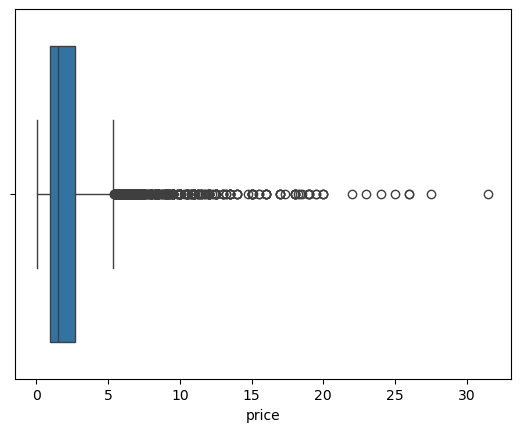

In [240]:
sns.boxplot(x=df['price'])

In [241]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [242]:
print(lower_bound, upper_bound)

-1.7500000000000004 5.370000000000001


In [243]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

In [244]:
outliers['price'].describe()

count    436.000000
mean       9.169014
std        4.052769
min        5.400000
25%        6.300000
50%        8.000000
75%       10.552500
max       31.500000
Name: price, dtype: float64

In [245]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2283,house,arjun marg/ sector- 26 phase- 1/ golf course road,31.50,sector 26,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,0,101.0
2749,house,NaN,27.50,sector 43,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,0.0
356,house,NaN,26.00,sector 26,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72.0
2907,house,dlf city plots,26.00,sector 26,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,7.0
908,house,suncity township,25.00,sector 54,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,1,99.0
1570,house,emaar the palm springs,24.00,sector 54,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,83.0
2382,house,NaN,23.00,sector 26,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,2,67.0
2909,house,vipul tatvam villa,22.00,sector 48,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,1,53.0
1403,house,luxury dlf city floors,20.00,sector 26,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,2,24.0
2165,house,dlf city plots,20.00,sector 26,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,0.0


In [246]:
num_outliers =  outliers.shape[0]
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3863 entries, 0 to 3862
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3863 non-null   object 
 1   society              3342 non-null   object 
 2   price                3862 non-null   float64
 3   sector               3863 non-null   object 
 4   price_per_sqft       3862 non-null   float64
 5   area                 3862 non-null   float64
 6   areaWithType         3863 non-null   object 
 7   bedRoom              3863 non-null   int64  
 8   bathroom             3863 non-null   int64  
 9   balcony              3863 non-null   object 
 10  floorNum             3842 non-null   float64
 11  facing               2727 non-null   object 
 12  agePossession        3863 non-null   object 
 13  super_built_up_area  1926 non-null   float64
 14  built_up_area        1774 non-null   float64
 15  carpet_area          1975 non-null   f

/tmp/ipykernel_5910/90910361.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

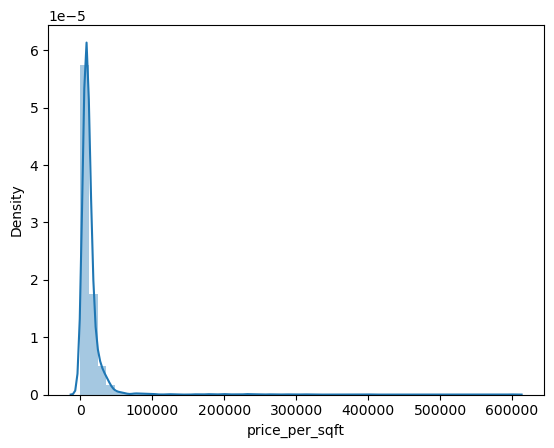

In [248]:
# price_per_sqft

sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

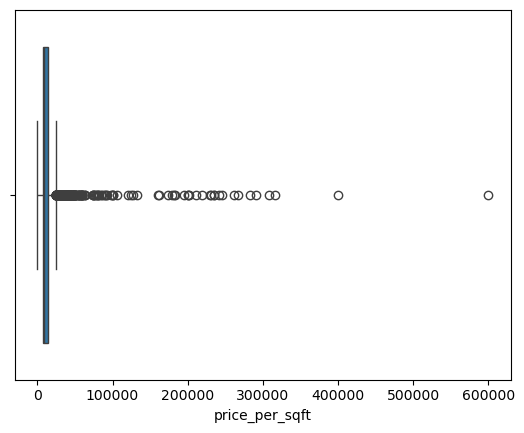

In [249]:
sns.boxplot(data = df, x = 'price_per_sqft')

In [250]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

In [251]:
# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(375,
 count       375.00000
 mean      52647.49600
 std       60441.09058
 min       24202.00000
 25%       27778.00000
 50%       33333.00000
 75%       42208.00000
 max      600000.00000
 Name: price_per_sqft, dtype: float64)

In [252]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x*9 if x < 1000 else x )

/tmp/ipykernel_5910/260571882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x*9 if x < 1000 else x )


In [253]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/tmp/ipykernel_5910/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [254]:
outliers_sqft['price_per_sqft'].describe()

count      375.000000
mean     28721.381333
std      12549.598665
min       2689.000000
25%      24845.000000
50%      29333.000000
75%      35348.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [255]:
df.update(outliers_sqft)

/tmp/ipykernel_5910/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

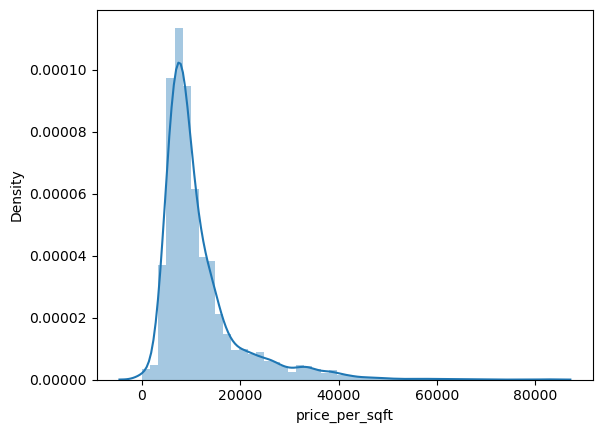

In [256]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

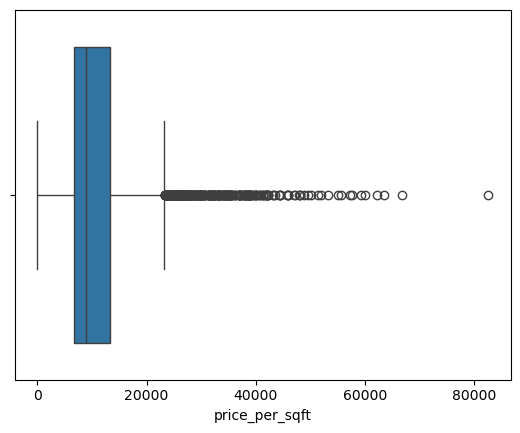

In [257]:
sns.boxplot(data = df, x = 'price_per_sqft')

In [258]:
df[df['price_per_sqft']>50000]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
28,house,emaar mgf marbella,18.00,sector 66,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,0,75.0
169,house,project housing board colony,8.00,sector 31,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,No,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,1,0.0
335,house,NaN,14.75,sector 26,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,153.0
356,house,NaN,26.00,sector 26,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72.0
435,house,emaar the palm springs,14.00,sector 54,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,2,160.0
909,house,malibu towne,8.50,sector 47,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,2,67.0
1570,house,emaar the palm springs,24.00,sector 54,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,83.0
2435,house,nul,12.50,sector 28,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,0,32.0
2515,house,cloudnine cottages,5.50,sector 48,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,No,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,1,49.0
2907,house,dlf city plots,26.00,sector 26,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,7.0


In [259]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

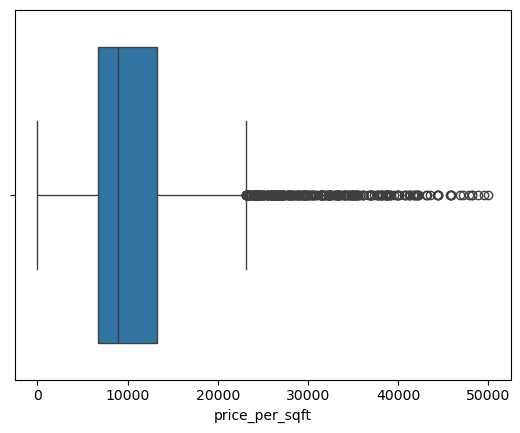

In [260]:
sns.boxplot(data = df, x = 'price_per_sqft')

In [261]:
# Area
df['area'].describe()

count      3849.000000
mean       2895.399844
std       22607.150326
min         145.000000
25%        1250.000000
50%        1743.000000
75%        2340.000000
max      875000.000000
Name: area, dtype: float64

/tmp/ipykernel_5910/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

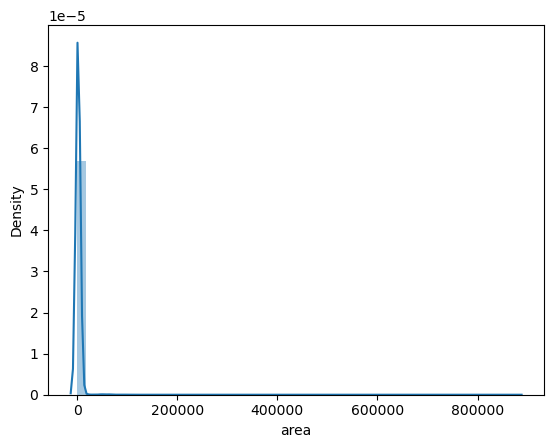

In [262]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

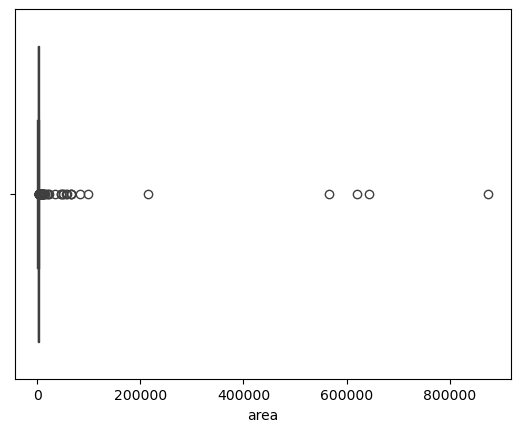

In [263]:
sns.boxplot(data = df, x = 'area')

In [264]:
df[df['area'] > 100000]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1778,flat,signature the roselia,0.45,sector 95a,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,1,52.0
2076,flat,hcbs sports ville,0.35,sohna,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,0,21.0
2201,flat,ramsons kshitij,0.31,sector 95,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,1,65.0
2519,flat,signature global solera 2,0.51,sector 107,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,1,0.0
2775,house,NaN,5.00,sector 50,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,2,0.0


In [265]:
df = df[df['area'] <= 10000]

<Axes: xlabel='area'>

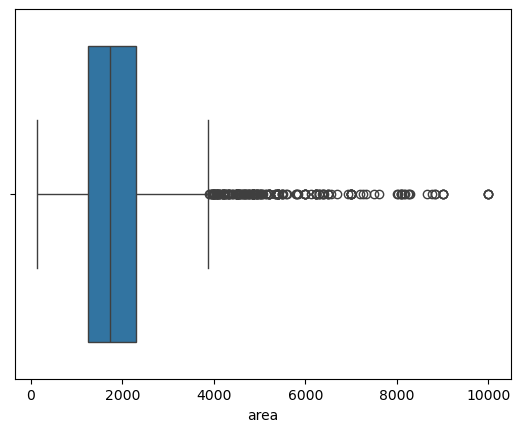

In [266]:
sns.boxplot(data = df, x = 'area')

/tmp/ipykernel_5910/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

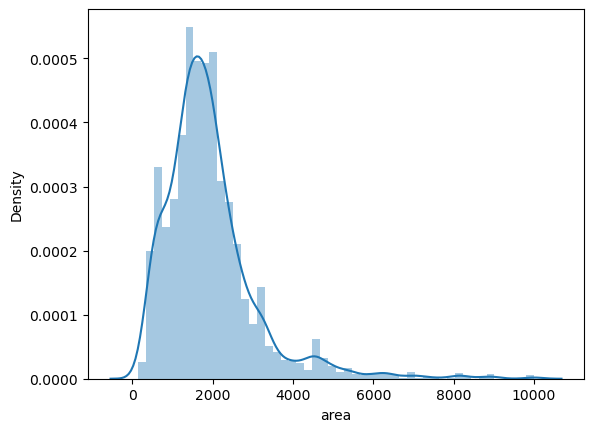

In [267]:
sns.distplot(df['area'])

In [268]:
# Calculate the IQR for the 'area' column
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_area = df[(df['area'] < lower_bound) | (df['area'] > upper_bound)]
print(lower_bound, upper_bound)

-339.0 3885.0


In [269]:
outliers_area['area'].describe()

count      227.000000
mean      5389.806167
std       1414.667251
min       3900.000000
25%       4500.000000
50%       4860.000000
75%       6000.000000
max      10000.000000
Name: area, dtype: float64

In [270]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

/tmp/ipykernel_5910/2949369691.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

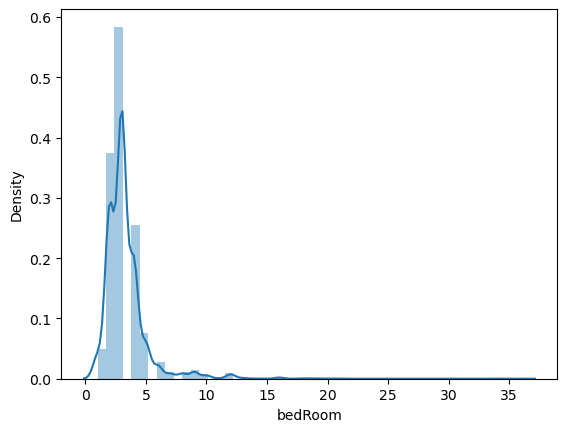

In [271]:
# bedRoom
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

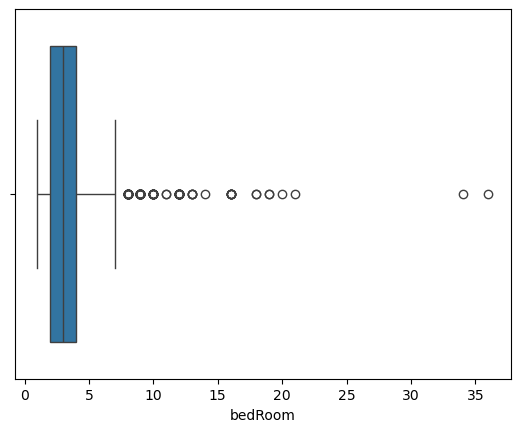

In [272]:
sns.boxplot(data = df, x = 'bedRoom')

In [273]:
df['bedRoom'].describe()

count    3823.000000
mean        3.323568
std         1.944194
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: bedRoom, dtype: float64

In [274]:
Q1 = df['bedRoom'].quantile(0.25)
Q3 = df['bedRoom'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [275]:
lower_bound, upper_bound

(-1.0, 7.0)

In [276]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3487,house,NaN,2.25,west sector 13,6944.0,3240.0,Plot area 360(301.01 sq.m.),36,36,2,3.0,East,Moderately Old,NaN,3240.0,NaN,0,1,0,0,0,1,79.0
2427,house,manohar nagar,5.60,sector 12,12444.0,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,2,0.0
2040,house,NaN,5.00,sector 54,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,0,21.0
1107,house,NaN,4.50,sector 43,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,0,52.0
3420,house,NaN,3.87,sector 17a,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,1,26.0
3458,house,NaN,3.93,sector 17a,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,1,49.0
372,house,NaN,5.50,sector 76,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,0,70.0
1824,house,private house,7.05,sector 55,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,0,85.0
736,house,NaN,13.50,sector 43,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,1,41.0
1403,house,luxury dlf city floors,20.00,sector 26,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,2,24.0


In [277]:
df = df[df['bedRoom']<=10]

In [278]:
df.shape

(3775, 23)

/tmp/ipykernel_5910/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

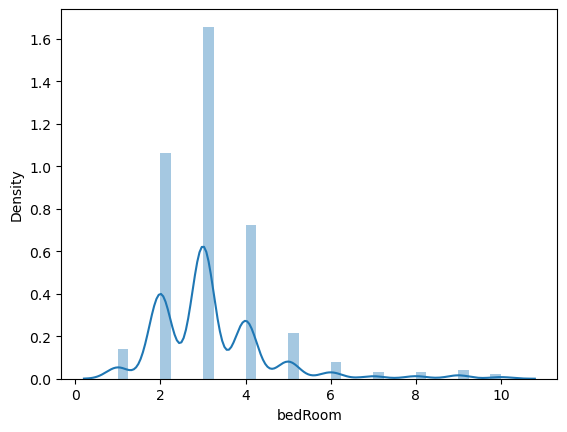

In [279]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

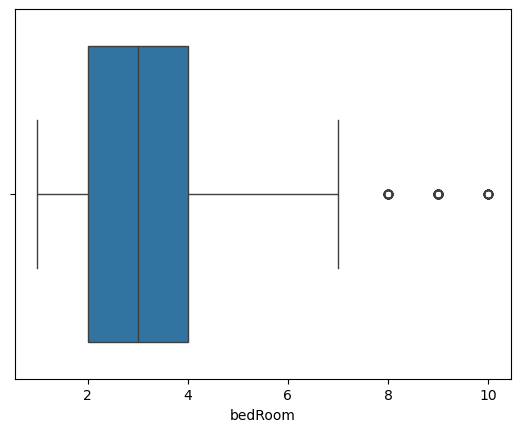

In [280]:
sns.boxplot(data = df, x = 'bedRoom')

/tmp/ipykernel_5910/367417139.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

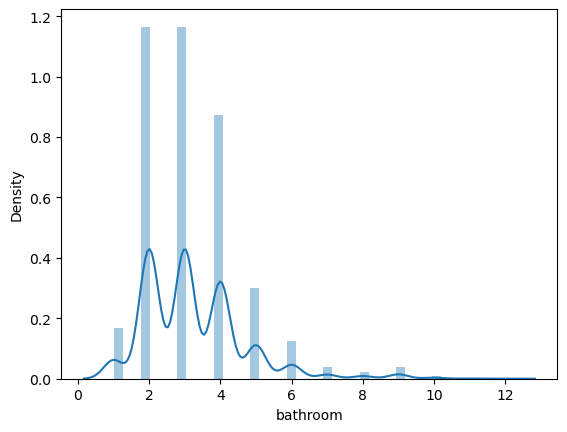

In [281]:
# bathroom
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

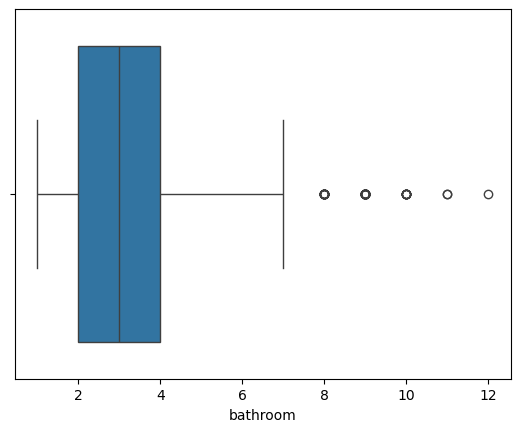

In [282]:
sns.boxplot(data = df, x = 'bathroom')

In [283]:
df['bathroom'].describe()

count    3775.000000
mean        3.241854
std         1.439118
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000
Name: bathroom, dtype: float64

In [284]:
df[df['bathroom']> 10]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
963,house,adani brahma samsara,18.02,sector 60,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,2,20.0
1094,house,NaN,7.00,sector 39,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,49.0
1961,house,NaN,11.00,sector 25,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,2,90.0


/tmp/ipykernel_5910/2888444933.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

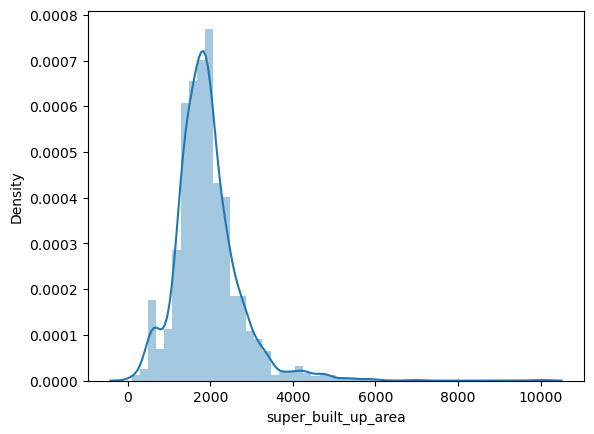

In [285]:
# super_built_up_area

sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

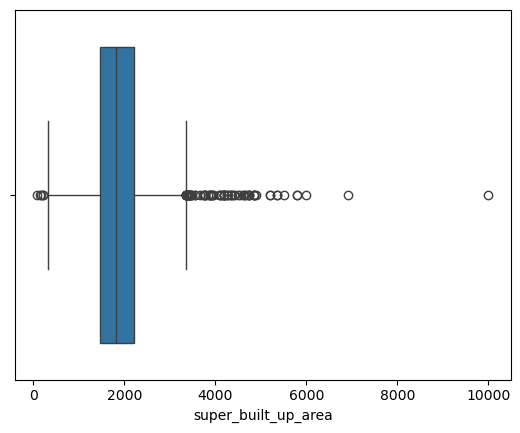

In [286]:
sns.boxplot(data = df, x = 'super_built_up_area')

In [287]:
df['super_built_up_area'].describe()

count     1926.000000
mean      1918.763006
std        767.294289
min         89.000000
25%       1457.000000
50%       1826.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [288]:
df[df['super_built_up_area'] > 6000]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
187,flat,krrish provence estate,7.5,sector 2,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,1,49.0
2249,flat,bestech park view grand spa,4.7,sector 81,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,2,0.0


/tmp/ipykernel_5910/2302651318.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

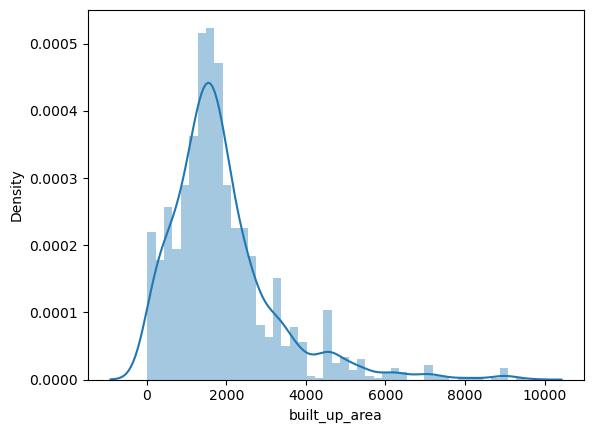

In [289]:
# built_up_area
sns.distplot(df['built_up_area'])

In [290]:
df['built_up_area'].skew()

1.8668520235002788

In [291]:
df['built_up_area'].kurtosis()

5.316947007376703

<Axes: xlabel='built_up_area'>

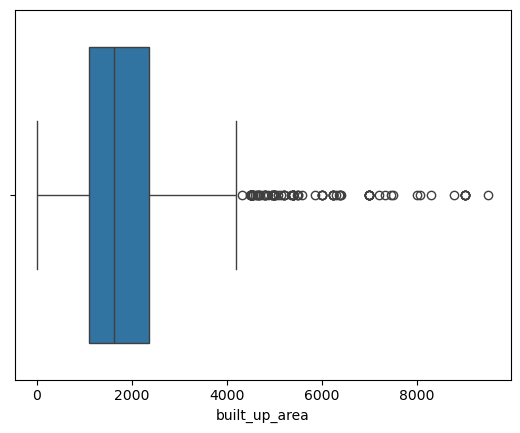

In [292]:
sns.boxplot(data = df, x = 'built_up_area')

In [293]:
df[df['built_up_area'] > 8000].shape

(10, 23)

/tmp/ipykernel_5910/2977382181.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

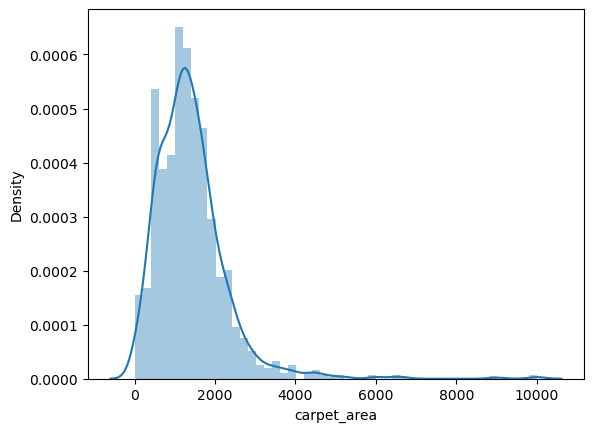

In [294]:
# carpet_area
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

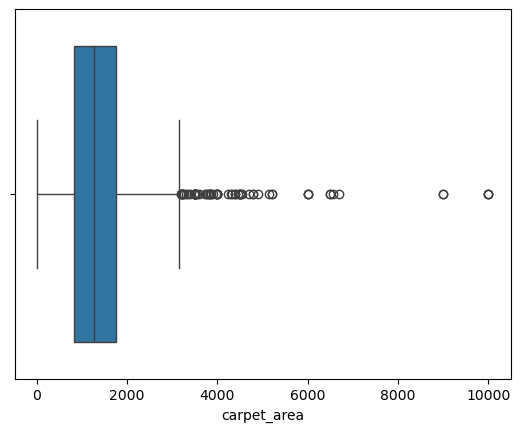

In [295]:
sns.boxplot(data = df, x = 'carpet_area')

In [296]:
df[df['carpet_area'] > 6000]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
161,flat,ats triumph,4.45,sector 104,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,27.0,North,Relatively New,NaN,NaN,6500.0,0,0,0,0,0,1,110.0
656,house,NaN,10.00,sector 25,37037.0,2700.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,3.0,East,Moderately Old,NaN,9500.0,9000.0,0,1,0,1,0,0,29.0
924,flat,tata gurgaon gateway,6.00,sector 113,9139.0,6565.0,Carpet area: 6565 (609.91 sq.m.),5,6,3+,24.0,North,Moderately Old,NaN,NaN,6565.0,0,0,0,0,0,1,149.0
1712,flat,the penthouses at the hibiscus,8.50,sector 50,8500.0,10000.0,Carpet area: 10000 (929.03 sq.m.),4,4,3,9.0,South-East,Moderately Old,NaN,NaN,10000.0,0,1,0,0,0,1,38.0
2109,flat,the penthouses at the hibiscus,8.00,sector 50,8888.0,9001.0,Carpet area: 9000 (836.13 sq.m.),4,3,3,7.0,South-East,Moderately Old,NaN,NaN,9000.0,0,1,0,0,0,1,88.0
2336,house,ansal sushant lok plots,11.50,sector 43,17692.0,6500.0,Plot area 3762(349.5 sq.m.)Built Up area: 9000...,7,8,3+,3.0,NaN,Old Property,NaN,9000.0,6500.0,0,1,1,1,0,2,0.0
2840,flat,central park resorts,15.00,sector 48,22388.0,6700.0,Carpet area: 6700 (622.45 sq.m.),5,6,3+,17.0,NaN,Relatively New,NaN,NaN,6700.0,1,1,0,1,0,0,123.0
3229,house,NaN,8.00,sector 25,8000.0,10000.0,Carpet area: 10000 (929.03 sq.m.),3,9,2,3.0,NaN,New Property,NaN,NaN,10000.0,0,0,0,0,0,1,49.0
3486,house,NaN,18.25,sector 26,18250.0,10000.0,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,4.0,East,Relatively New,NaN,NaN,10000.0,1,1,1,1,0,2,49.0


In [297]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

185.14666666666668

In [298]:
df[df['area']/df['area'] < 183 ]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.00,0,1,0,0,0,1,43.0
2,flat,tulip monsella,7.40,sector 53,33199.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.00,0,0,0,0,0,1,35.0
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.00,0,0,0,1,0,1,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,flat,bestech park view ananda,1.45,sector 81,8734.0,1660.0,Super Built up area 1660(154.22 sq.m.)Carpet a...,3,2,3+,3.0,NaN,Relatively New,1660.0,NaN,1082.00,0,0,0,0,1,1,NaN
3859,house,NaN,0.60,sector 9,10753.0,558.0,Plot area 62(51.84 sq.m.),2,2,1,1.0,North-East,Moderately Old,NaN,558.0,NaN,0,0,0,0,0,1,NaN
3860,flat,puri the aravallis,3.87,sector 61,17200.0,2250.0,Super Built up area 2250(209.03 sq.m.)Carpet a...,3,4,3+,21.0,East,Under Construction,2250.0,NaN,1249.65,0,1,0,0,0,1,NaN
3861,house,NaN,4.35,sector 46,23693.0,1836.0,Plot area 204(170.57 sq.m.),8,8,2,3.0,North-East,Relatively New,NaN,1836.0,NaN,1,0,0,1,0,2,NaN


In [299]:
df[['area','bedRoom']].value_counts()

area     bedRoom
1650.0   3          51
1950.0   3          35
2000.0   3          30
1350.0   2          24
2150.0   3          21
                    ..
1534.0   3           1
1531.0   2           1
1530.0   6           1
1527.0   3           1
10000.0  7           1
Name: count, Length: 1717, dtype: int64

In [300]:
df[df['area'] == 145.0]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2478,house,NaN,0.32,sector 88,22068.0,145.0,Built Up area: 145 (13.47 sq.m.),2,2,No,3.0,NaN,Undefined,NaN,145.0,NaN,0,0,0,0,0,1,159.0


In [301]:
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

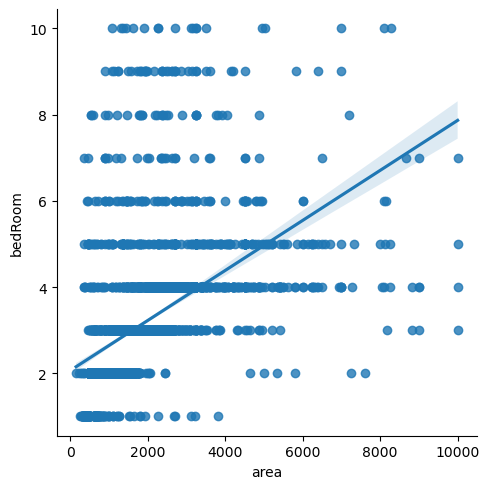

In [302]:
sns.lmplot(data = df, x = 'area', y = 'bedRoom' )

In [303]:
df['area_room_ratio'] = df['area']/ df['bedRoom']

In [304]:
(df[df['area_room_ratio']< 250])['bedRoom'].value_counts()

bedRoom
2     49
3     36
5     28
6     20
4     19
9     17
8     12
7      9
10     8
Name: count, dtype: int64

In [305]:
df = df[df['area_room_ratio'] > 100]

In [306]:
outliers_area = df[(df['area_room_ratio']< 250) & (df['bedRoom'] > 3)]

In [307]:
outliers_area['bedRoom'] = round(outliers_area['bedRoom'] / outliers_area['floorNum'])

/tmp/ipykernel_5910/4027658500.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_area['bedRoom'] = round(outliers_area['bedRoom'] / outliers_area['floorNum'])


In [308]:
df.update(outliers_area)

In [310]:
df

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0,786.000000
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.00,0,1,0,0,0,1,43.0,650.000000
2,flat,tulip monsella,7.40,sector 53,33199.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.00,0,0,0,0,0,1,35.0,557.250000
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0,456.666667
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.00,0,0,0,1,0,1,59.0,300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3858,flat,bestech park view ananda,1.45,sector 81,8734.0,1660.0,Super Built up area 1660(154.22 sq.m.)Carpet a...,3,2,3+,3.0,NaN,Relatively New,1660.0,NaN,1082.00,0,0,0,0,1,1,NaN,553.333333
3859,house,NaN,0.60,sector 9,10753.0,558.0,Plot area 62(51.84 sq.m.),2,2,1,1.0,North-East,Moderately Old,NaN,558.0,NaN,0,0,0,0,0,1,NaN,279.000000
3860,flat,puri the aravallis,3.87,sector 61,17200.0,2250.0,Super Built up area 2250(209.03 sq.m.)Carpet a...,3,4,3+,21.0,East,Under Construction,2250.0,NaN,1249.65,0,1,0,0,0,1,NaN,750.000000
3861,house,NaN,4.35,sector 46,23693.0,1836.0,Plot area 204(170.57 sq.m.),3,8,2,3.0,North-East,Relatively New,NaN,1836.0,NaN,1,0,0,1,0,2,NaN,229.500000


In [311]:
df['area_room_ratio'] = df['area']/ df['bedRoom']

In [312]:
df[(df['area_room_ratio']< 250) & (df['bedRoom'] > 4)]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
321,house,NaN,3.50,sector 11,15555.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10,1,No,1.0,NaN,New Property,NaN,2250.0,NaN,0,0,0,0,0,1,0.0,225.000000
382,house,NaN,0.80,imt manesar,6666.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,Relatively New,NaN,1200.0,NaN,0,0,0,0,0,1,0.0,150.000000
825,house,NaN,1.10,manesar,6172.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,No,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,1,0.0,222.750000
1001,house,NaN,0.85,sector 5,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,1,104.0,180.000000
1295,house,NaN,1.65,sector 5,8333.0,1980.0,Built Up area: 220 (20.44 sq.m.),9,9,No,1.0,NaN,New Property,NaN,220.0,NaN,0,0,0,0,0,1,38.0,220.000000
1407,house,NaN,0.65,sector 62,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,1,13.0,166.666667
1832,house,NaN,0.32,sector 88,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5,1,No,1.0,NaN,Undefined,NaN,565.0,NaN,0,0,0,0,0,1,54.0,113.000000
2592,house,"bhim nagar, sector 6",0.85,sector 6,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,NaN,67.0,NaN,0,0,0,1,0,1,60.0,120.600000
2967,house,shivpuri,2.80,sector 7,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,2,31.0,225.000000
3168,house,NaN,1.10,sector 105,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,1,169.0,150.000000


In [313]:
df = df[~((df['area_room_ratio']< 250) & (df['bedRoom'] > 4))]

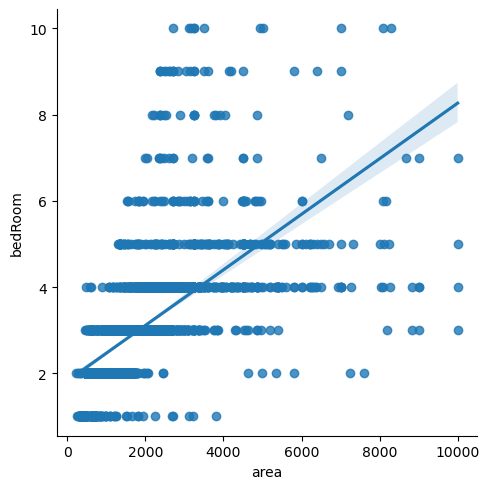

In [314]:
sns.lmplot(data = df, x = 'area', y = 'bedRoom' )

In [315]:
df.to_csv('gurgaon_properties_outliers_treatment.csv')